## Import packages

In [31]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src import fetch_stock_data
from src import (
    check_data_quality,
    handle_missing_values,
    remove_duplicates,
    detect_outliers,
    handle_outliers,
    detect_anomalous_returns,
    clean_pipeline
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black'
})
sns.set_palette("husl")

## Fetch raw data

In [32]:

ticker = "AAPL"
df = fetch_stock_data(ticker=ticker, period="2y", interval="1d")
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-03-14,171.439774,172.737957,170.498344,171.350589,72913500
2024-03-15,171.063187,171.063187,168.754198,169.626267,121752700
2024-03-18,172.153244,176.107264,171.955051,173.986565,75604200
2024-03-19,174.491989,175.017208,171.469493,172.767676,55215200
2024-03-20,177.058624,177.058624,173.510909,174.135233,53423100


## Run data quality report

In [33]:
report = check_data_quality(df)

DATA QUALITY REPORT
Total rows: 501
Date range: 2024-03-14 to 2026-03-13
Total missing values: 0
Duplicate dates: 0

Missing per column:
  Close: 0
  High: 0
  Low: 0
  Open: 0
  Volume: 0


## Check for duplicate dates

In [34]:
duplicates = df.index[df.index.duplicated()]
print(f"Duplicate dates found: {len(duplicates)}")
if len(duplicates) > 0:
    print(duplicates)

df = remove_duplicates(df)

Duplicate dates found: 0
Duplicates removed: 0


## Handle missing values

In [35]:
print("Before cleaning:")
print(df.isnull().sum())
print()

df = handle_missing_values(df, method="interpolate")

print("\nAfter cleaning:")
print(df.isnull().sum())

Missing values: 0 → 0 (method: interpolate)

After cleaning:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


## Visualize missing data pattern

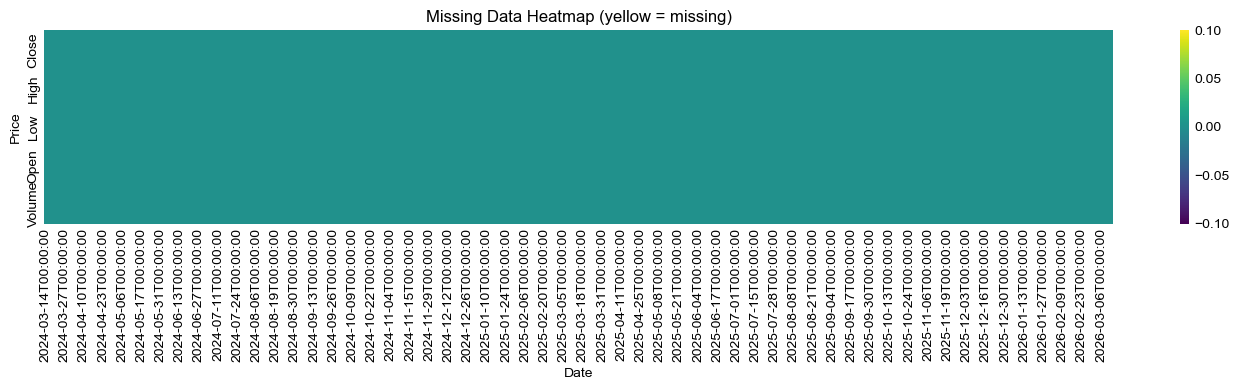

In [36]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df.isnull().T, cbar=True, cmap='viridis', yticklabels=True, ax=ax)
ax.set_title('Missing Data Heatmap (yellow = missing)')
plt.tight_layout()
plt.show()

## Detect outliers in Close price

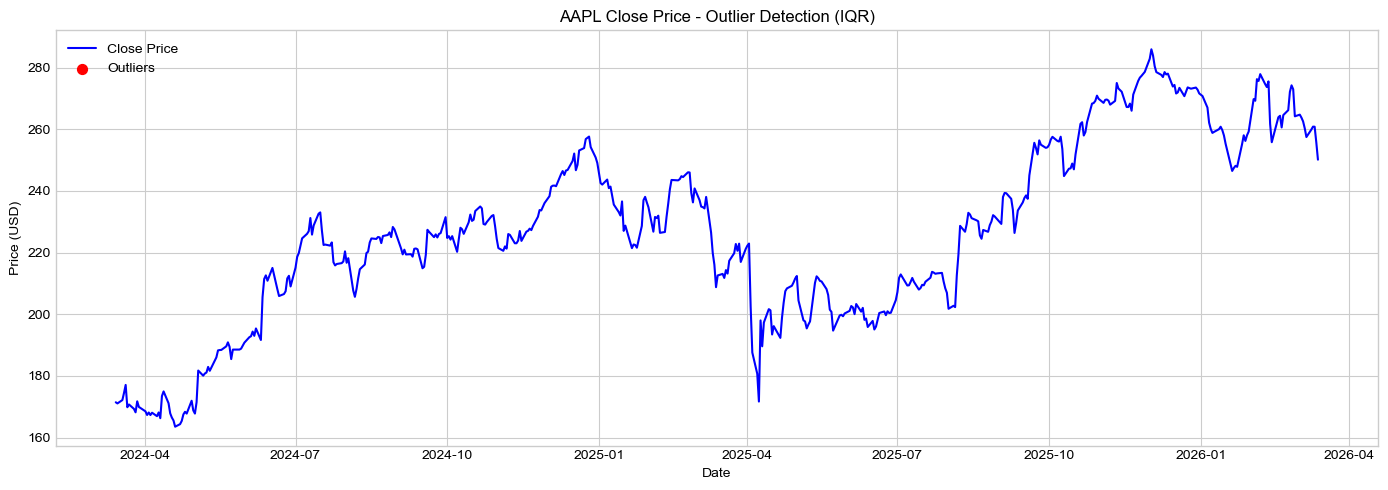

In [37]:
outliers_close = detect_outliers(df, column="Close", method="iqr", threshold=1.5)

plt.figure(figsize=(14, 5))
plt.plot(df['Close'], label='Close Price', color='blue')
plt.scatter(df.index[outliers_close], df['Close'][outliers_close],
            color='red', label='Outliers', zorder=5, s=50)
plt.title(f'{ticker} Close Price - Outlier Detection (IQR)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Detect outliers in Volume

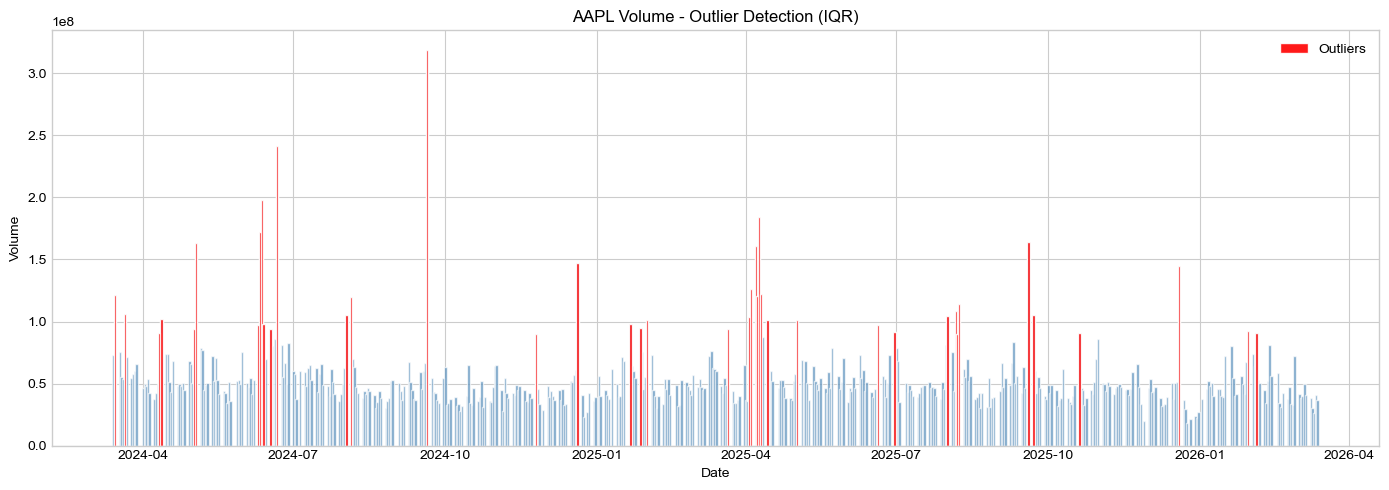

In [38]:

outliers_volume = detect_outliers(df, column="Volume", method="iqr", threshold=1.5)

plt.figure(figsize=(14, 5))
plt.bar(df.index, df['Volume'], color='steelblue', alpha=0.7, width=1.5)
plt.bar(df.index[outliers_volume], df['Volume'][outliers_volume],
        color='red', alpha=0.9, width=1.5, label='Outliers')
plt.title(f'{ticker} Volume - Outlier Detection (IQR)')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.tight_layout()
plt.show()

## Detect outliers using Z-score

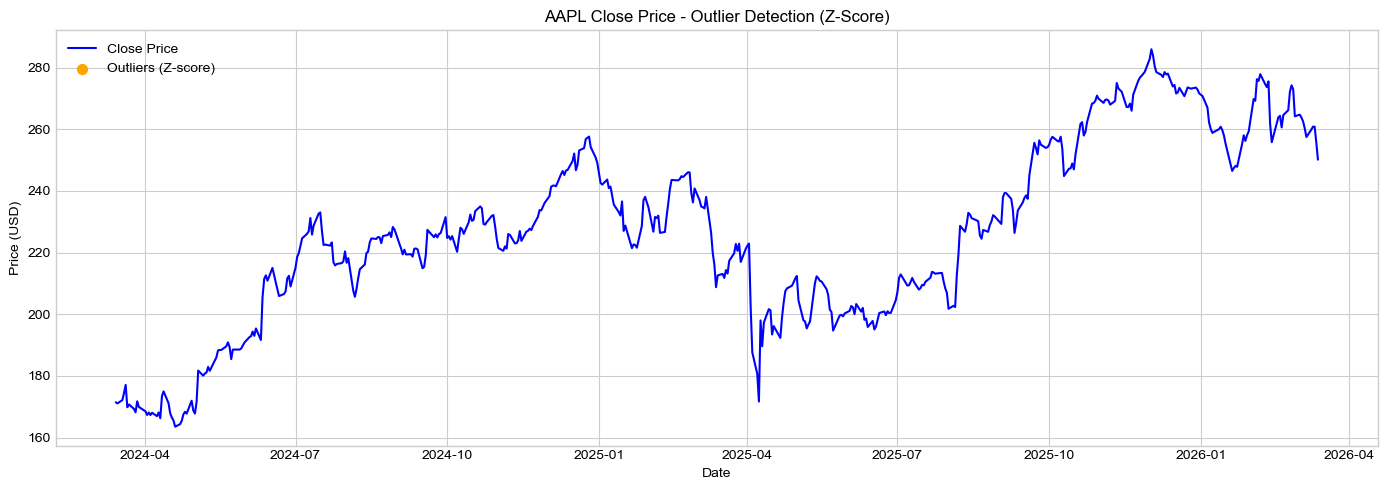

In [39]:

outliers_zscore = detect_outliers(df, column="Close", method="zscore", threshold=3)

plt.figure(figsize=(14, 5))
plt.plot(df['Close'], label='Close Price', color='blue')
plt.scatter(df.index[outliers_zscore], df['Close'][outliers_zscore],
            color='orange', label='Outliers (Z-score)', zorder=5, s=50)
plt.title(f'{ticker} Close Price - Outlier Detection (Z-Score)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## Detect anomalous daily returns

In [40]:

anomalies = detect_anomalous_returns(df, column="Close", max_daily_pct=10.0)

Anomalous daily changes (>10.0%): 1
Price            Close  pct_change
Date                              
2025-04-09  197.987106   15.328857


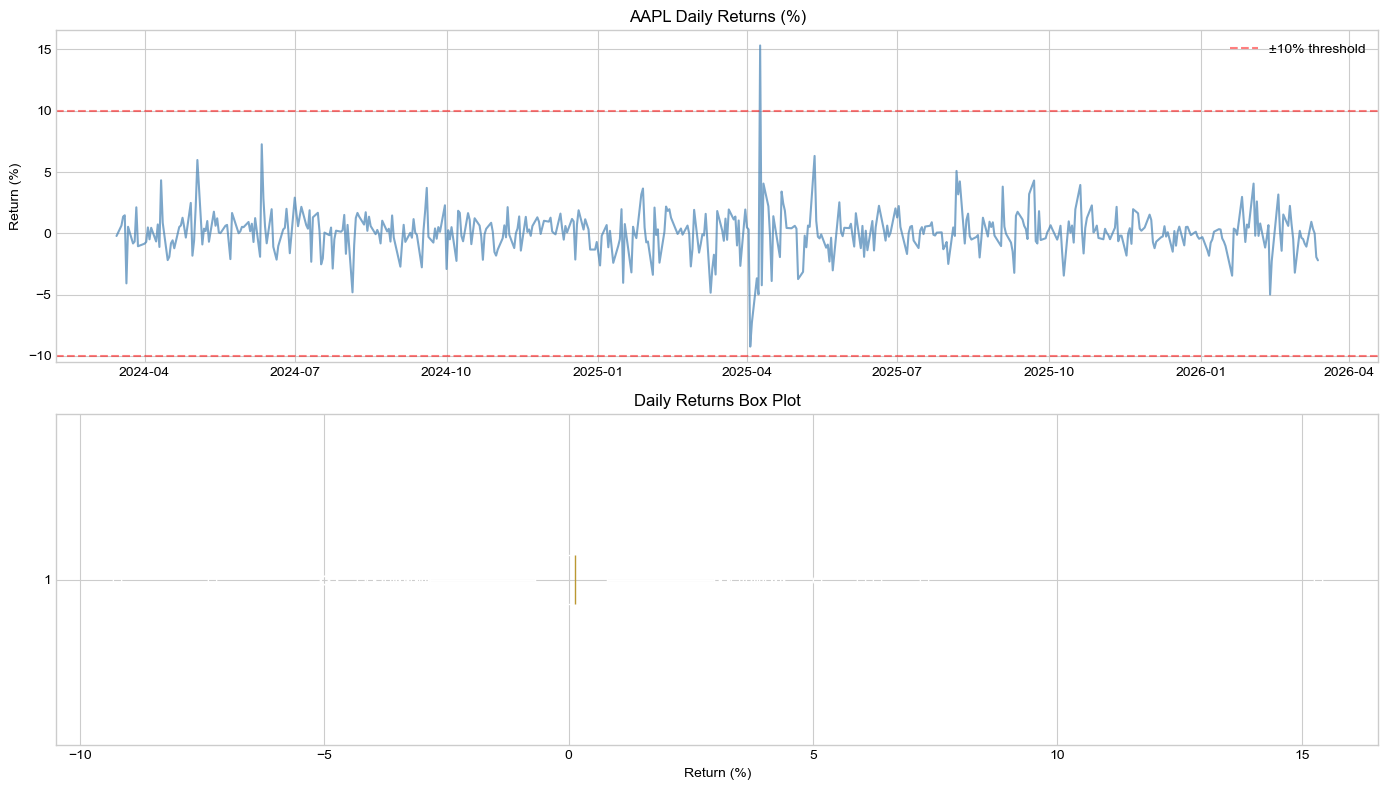

In [41]:
## Cell 11: Visualize daily returns for anomaly inspection
daily_returns = df['Close'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(daily_returns, color='steelblue', alpha=0.7)
axes[0].axhline(y=10, color='red', linestyle='--', alpha=0.5, label='±10% threshold')
axes[0].axhline(y=-10, color='red', linestyle='--', alpha=0.5)
axes[0].set_title(f'{ticker} Daily Returns (%)')
axes[0].set_ylabel('Return (%)')
axes[0].legend()

axes[1].boxplot(daily_returns.dropna(), vert=False)
axes[1].set_title('Daily Returns Box Plot')
axes[1].set_xlabel('Return (%)')

plt.tight_layout()
plt.show()

## Run full cleaning pipeline

In [42]:
df_raw = fetch_stock_data(ticker=ticker, period="5y", interval="1d")
df_clean = clean_pipeline(df_raw, missing_method="interpolate", outlier_threshold=3.0)

## Before vs after comparison

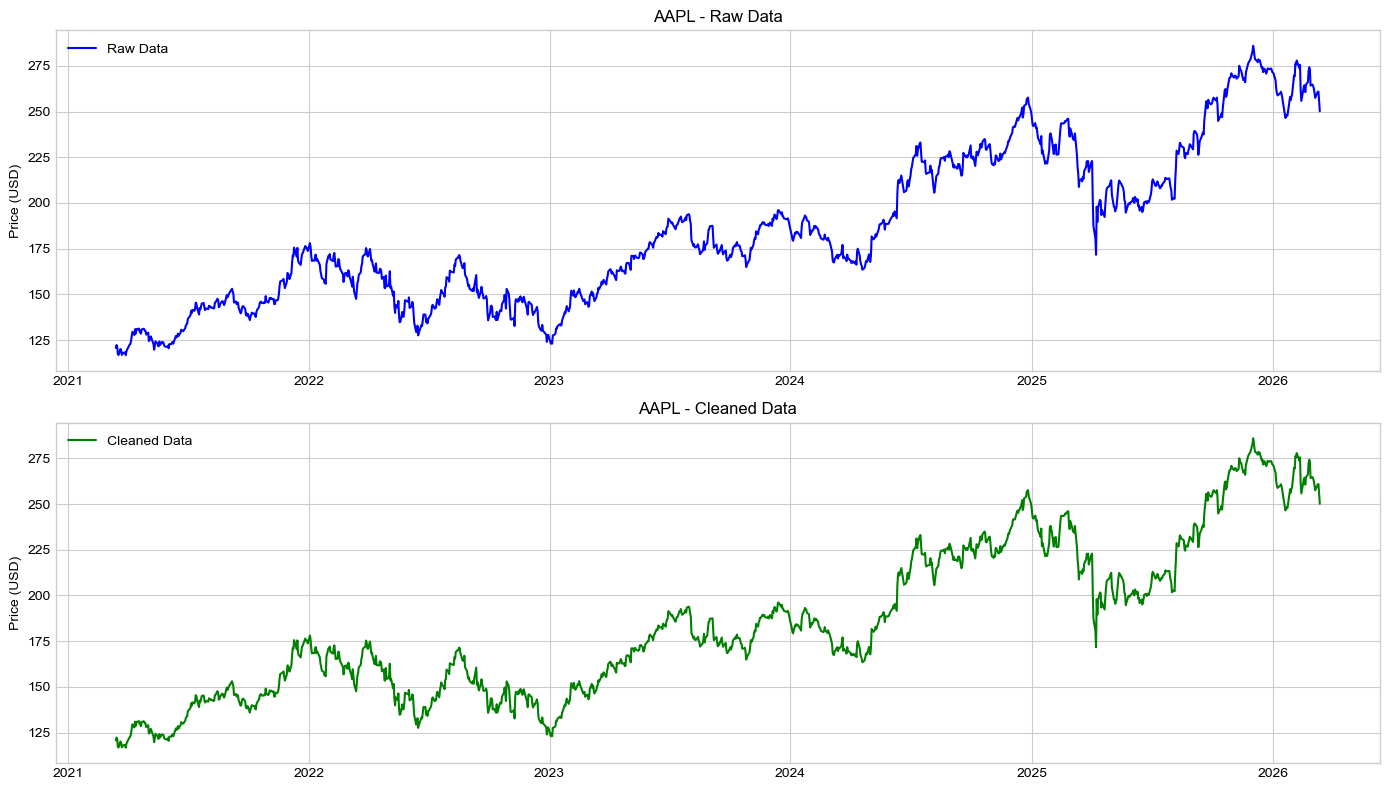

In [43]:

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_raw['Close'], label='Raw Data', color='blue')
axes[0].set_title(f'{ticker} - Raw Data')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

axes[1].plot(df_clean['Close'], label='Cleaned Data', color='green')
axes[1].set_title(f'{ticker} - Cleaned Data')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Save cleaned data

In [44]:

import os
os.makedirs('../data/raw', exist_ok=True)

df_clean.to_csv('../data/raw/cleaned_data.csv')
print(f"Cleaned data saved to ../data/raw/cleaned_data.csv")
print(f"Shape: {df_clean.shape}")

Cleaned data saved to ../data/raw/cleaned_data.csv
Shape: (1256, 5)


## Summary

In [45]:

print("=" * 50)
print(f"DATA CLEANING SUMMARY - {ticker}")
print("=" * 50)
print(f"Raw data points: {len(df_raw)}")
print(f"Cleaned data points: {len(df_clean)}")
print(f"Rows removed: {len(df_raw) - len(df_clean)}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
print(f"Outliers (IQR Close): {outliers_close.sum()}")
print(f"Outliers (Z-score Close): {outliers_zscore.sum()}")
print(f"Anomalous returns: {len(anomalies)}")
print("=" * 50)
print("\nNext: 03_feature_engineering.ipynb")

DATA CLEANING SUMMARY - AAPL
Raw data points: 1256
Cleaned data points: 1256
Rows removed: 0
Missing values remaining: 0
Outliers (IQR Close): 0
Outliers (Z-score Close): 0
Anomalous returns: 1

Next: 03_feature_engineering.ipynb
